In [1]:
from google.colab import files
files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


{'test.csv': b'Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition\n1461,20,RH,80,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA

In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Save the target before combining
y_train = train['SalePrice']
print(len(train))  # 1460 — you'll need this to split back

1460


In [5]:
combined_df = pd.concat([train.drop(columns=['SalePrice']), test], ignore_index=True)   #now we are marging train DF without y and test df.
print(combined_df.shape)

(2919, 80)


In [6]:
print(combined_df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      486
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


In [7]:
#coloumn with N/A or None or NA values or CATEGORIAL absence
none_cols = ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtExposure', 'BsmtCond', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']
combined_df[none_cols] = combined_df[none_cols].fillna('None')
# Colomn with 0 or NUMERIC absence
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
combined_df[zero_cols] = combined_df[zero_cols].fillna(0)


In [8]:
# --- LotFrontage: fill with median of same neighborhood ---
# a house in an expensive dense area likely has a different lot frontage than a suburban one.
#Different neighborhoods have different lot sizes. Using overall median would reduce accuracy.
combined_df['LotFrontage'] = combined_df.groupby('Neighborhood')['LotFrontage'] \
                                  .transform(lambda x: x.fillna(x.median()))

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Correlation of all numeric features with SalePrice ---
train_num = combined_df.iloc[:1460].select_dtypes(include='number').copy()
train_num['SalePrice'] = y_train.values

corr_with_target = train_num.corrwith(train_num['SalePrice']).abs().drop('SalePrice').sort_values(ascending=False)

print("=== Top 15 (strongest) ===")
print(corr_with_target.head(15))
print("\n=== Bottom 10 (weakest — drop candidates) ===")
print(corr_with_target.tail(10))

=== Top 15 (strongest) ===
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.347806
WoodDeckSF      0.324413
dtype: float64

=== Bottom 10 (weakest — drop candidates) ===
MSSubClass      0.084284
OverallCond     0.077856
MoSold          0.046432
3SsnPorch       0.044584
YrSold          0.028923
LowQualFinSF    0.025606
Id              0.021917
MiscVal         0.021190
BsmtHalfBath    0.016844
BsmtFinSF2      0.011378
dtype: float64


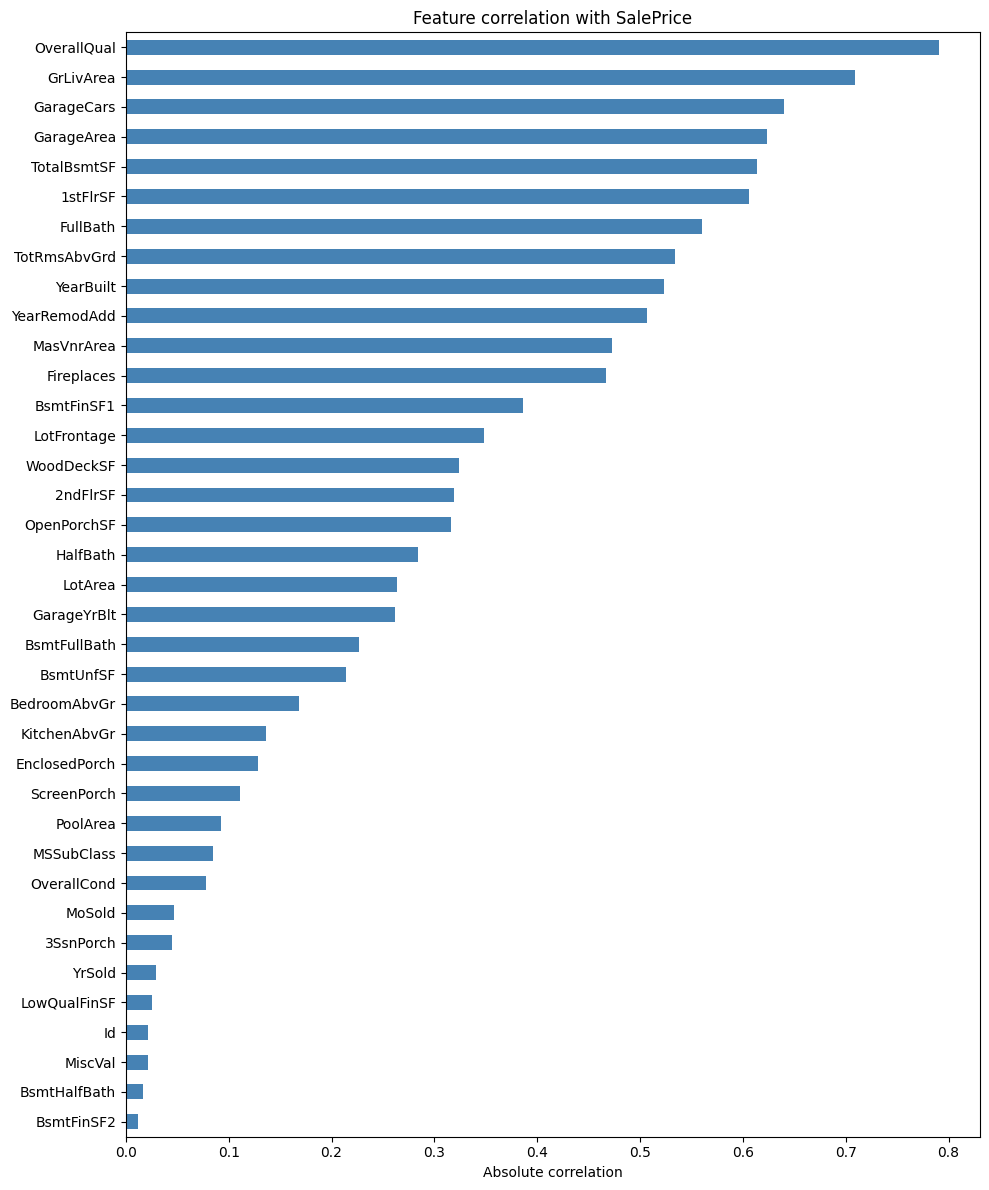

In [10]:
# --- 2. Bar chart of all feature correlations with SalePrice ---
plt.figure(figsize=(10, 12))
corr_with_target.plot(kind='barh', color='steelblue')
plt.title('Feature correlation with SalePrice')
plt.xlabel('Absolute correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
# --- 3. Feature vs feature correlation
# — find Multicollinearity pairs ---
corr_matrix = train_num.drop(columns='SalePrice').corr().abs()

# Extract upper triangle only (avoids duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Print all pairs above threshold
threshold = 0.7
high_corr_pairs = [(col, row, round(upper.loc[row, col], 3))
                   for col in upper.columns
                   for row in upper.index
                   if pd.notna(upper.loc[row, col]) and upper.loc[row, col] >= threshold]

high_corr_pairs.sort(key=lambda x: -x[2])
print(f"\n=== Feature pairs with r >= {threshold} ===")
for a, b, r in high_corr_pairs:
    print(f"  {a:20s} <-> {b:20s}  r = {r}")


=== Feature pairs with r >= 0.7 ===
  GarageArea           <-> GarageCars            r = 0.882
  TotRmsAbvGrd         <-> GrLivArea             r = 0.825
  1stFlrSF             <-> TotalBsmtSF           r = 0.82


GarageArea and GarageCars, TotRmsAbvGrd and GrLivArea, 1stFlrSF and TotalBsmtSF        

have Multicollinearity more than 0.7            

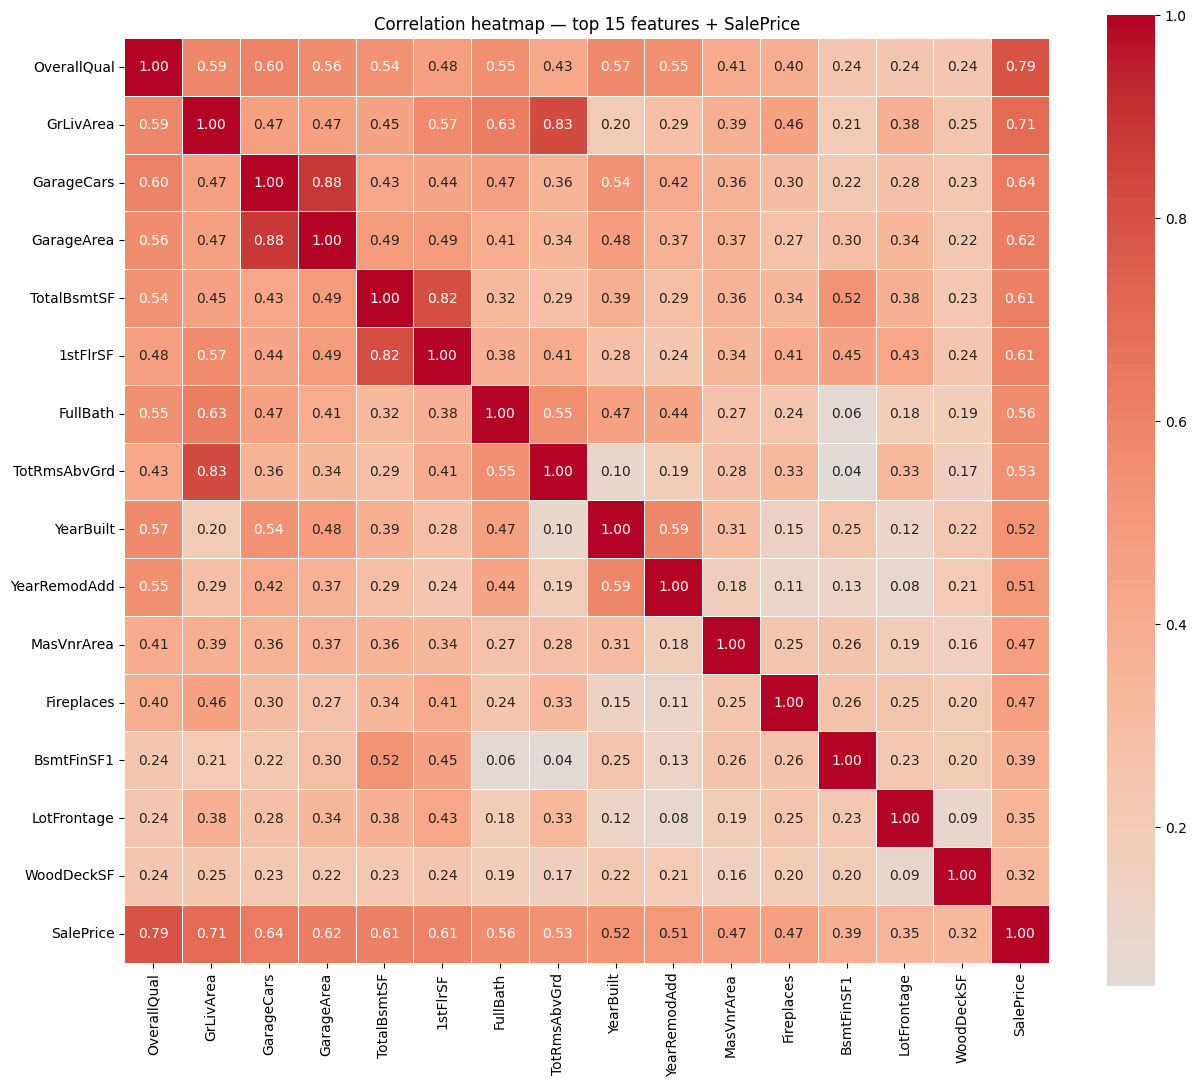

In [12]:
# --- 4. Heatmap of top 15 features only (full matrix is unreadable) ---
top15 = corr_with_target.head(15).index.tolist() + ['SalePrice']
corr_top = train_num[top15].corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation heatmap — top 15 features + SalePrice')
plt.tight_layout()
plt.show()

In [13]:
#ID is not an important features.
combined_df.drop('Id', axis=1, inplace=True)

In [14]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   int64  
 1   MSZoning       2915 non-null   object 
 2   LotFrontage    2919 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2917 non-null   object 
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuil

In [15]:
#Check categorical columns: for encoding the categorial columns
cat_cols = combined_df.select_dtypes(include='object').columns

print(f"Number of categorical columns: {len(cat_cols)}")

Number of categorical columns: 43


In [16]:
combined_encoded = pd.get_dummies(
    combined_df,
    columns=cat_cols,
    drop_first=True
)

In [17]:
X_train_full = combined_encoded.iloc[:1460, :] #Selects rows 0 to 1459
X_test_final = combined_encoded.iloc[1460:, :] #Selects rows 1460 to the end.

In [18]:
print(X_train_full.shape)
print(X_test_final.shape)

(1460, 260)
(1459, 260)


In [19]:
from sklearn.model_selection import train_test_split
#Train Set = Learn
#Validation Set = Evaluate
X_train, X_valid, y_train_split, y_valid = train_test_split(
    X_train_full,
    y_train,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn import linear_model

reg = linear_model.LinearRegression()
reg.fit(X_train,y_train_split)

LinearRegression()

In [21]:
reg_preds = reg.predict(X_valid)

In [22]:
from sklearn.metrics import root_mean_squared_error

reg_rmse = root_mean_squared_error(
    y_valid,
    reg_preds
)

print("RMSE:", reg_rmse)

RMSE: 83073.71611795876


In [23]:
from sklearn.metrics import mean_absolute_error
reg_mae = mean_absolute_error(y_valid, reg_preds)
print("reg_MAE:", reg_mae)

reg_MAE: 23945.777443705625


In [24]:
from sklearn.metrics import r2_score
reg_r2 = r2_score(y_valid, reg_preds)
print("reg_R2:", reg_r2)

reg_R2: 0.10026743019342377


R² = 0.10(my reg model explains 10% of the variation in house prices)

RMSE = 83,073(That means: On average, your house price predictions are off by roughly $83,073.)

House prices in this dataset are highly non-linear.

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train_split
)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=500, n_jobs=-1, random_state=42)

In [26]:
rf_preds = rf.predict(X_valid)

In [27]:
rf_rmse = root_mean_squared_error(
    y_valid,
    rf_preds
)

print(rf_rmse)

#RMSE penalizes large errors heavily, so lets check with MAE. When you square the error, big errors become disproportionately large.

29031.814838240836


In [28]:
from sklearn.metrics import mean_absolute_error
rf_mae = mean_absolute_error(y_valid, rf_preds)
print("rf_MAE:", rf_mae)

#MAE doesn't square the error

rf_MAE: 17589.38109087223


In [29]:
from sklearn.metrics import r2_score
rf_r2 = r2_score(y_valid, rf_preds)
print("rf_R²:", rf_r2)
# model explains 89% of why house prices vary across the dataset. The remaining 11% is noise your model can't capture yet

rf_R²: 0.8901159807242421


In [30]:
import numpy as np
rf_rmsle = np.sqrt(np.mean((np.log1p(rf_preds) - np.log1p(y_valid))**2))
print("rf_RMSLE:", rf_rmsle)
#RMSLE measures error in percentage/ratio terms, not raw dollars, so  expensive home has 6× the dollar error. predictions are off by about ±15% on average in log scale.
#RMSLE focuses on relative error, not absolute dollars.

rf_RMSLE: 0.15222100011006445


In [31]:
rf_mape = np.mean(np.abs((y_valid - rf_preds) / y_valid)) * 100
print(f"MAPE: {rf_mape:.2f}%")
#MAPE (Mean Absolute Percentage Error) tells the average percentage error in your predictions.


MAPE: 10.66%


rf_R² = 0.89(my reg model explains 89% of the variation in house prices)

rf_RMSE = 29,031(That means: On average, your house price predictions are off by roughly $29,031.)

rf_MAPE: 10.66% (My model's predictions are off by 10.66% of the actual price.)(MAPE < 10% Excellent)

rf_RMSLE: 0.15222100011006445 (My model predictions are off by about ±15% on average in log scale)

In [32]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
3,OverallQual,0.566564
15,GrLivArea,0.123457
11,TotalBsmtSF,0.033852
13,2ndFlrSF,0.031291
8,BsmtFinSF1,0.029685
12,1stFlrSF,0.028038
2,LotArea,0.016955
25,GarageCars,0.016309
26,GarageArea,0.015569
5,YearBuilt,0.013016


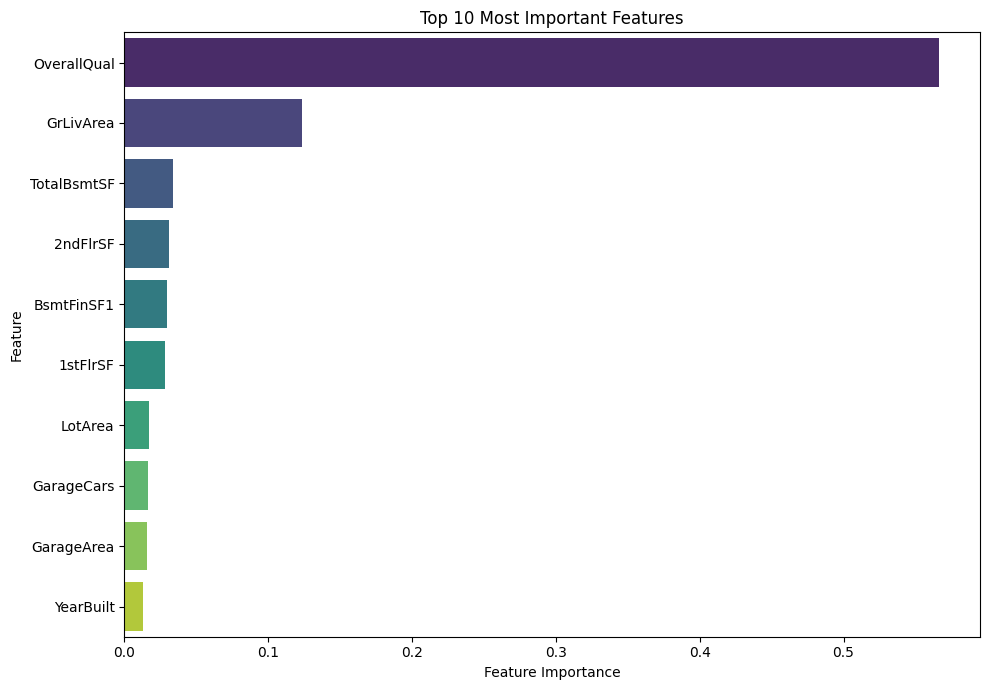

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define feature_importance (moved from EG0yzLW0r-OL to resolve NameError)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Get the top 10 features
top_10_features = feature_importance.head(10)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Most Important Features')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Feature Importance helps explain the model by identifying which variables have the greatest influence on house prices. It also helps with feature selection, model interpretation, and generating business insights.

GridSearchCV and RandomizedSearchCV are hyperparameter tuningGridSearchCV and

*   GridSearchCV: Grid Search tries every possible combination of hyperparameters that you specify.List item
*   When to use GridSearchCV?

*   You've already found a promising region.You want the absolute best parameters.The parameter space is small.
*   You've already found a promising region.You want the absolute best parameters.The parameter space is small

---

* RandomizedSearchCV automate the process of finding the best values.

* RandomizedSearchCV: Instead of trying all combinations, it randomly samples combinations.

* Hyper parameters for RF = n_estimators, max_depth, min_samples_split, min_samples_leaf, random_state, n_jobs

In [34]:
# ── Hyperparameter Tuning: RandomizedSearchCV first

from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Wide search across large parameter space to find a promising region
param_dist = {
    'n_estimators'     : [100, 200, 300, 500, 700],
    'max_depth'        : [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf' : [1, 2, 4, 6],
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5]
}

rf_random = RandomizedSearchCV(
    estimator   = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter      = 50,           # tries 50 random combinations out of all possible
    scoring     = 'neg_root_mean_squared_error',
    cv          = 5,            # 5-fold cross validation
    verbose     = 2,
    random_state= 42,
    n_jobs      = -1
)

rf_random.fit(X_train, y_train_split)

print("\n Best params from RandomizedSearchCV:")
print(rf_random.best_params_)
print(f" Best CV RMSE: {-rf_random.best_score_:,.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

 Best params from RandomizedSearchCV:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 15}
 Best CV RMSE: 29,680.89


In [35]:
# Final RF with best params from RandomizedSearchCV
rf_tuned = RandomForestRegressor(
    n_estimators     = 300,
    max_depth        = 15,
    min_samples_split= 2,
    min_samples_leaf = 1,
    max_features     = 0.3,
    random_state     = 42,
    n_jobs           = -1
)

rf_tuned.fit(X_train, y_train_split)
rf_tuned_preds = rf_tuned.predict(X_valid)

rf_tuned_rmse  = root_mean_squared_error(y_valid, rf_tuned_preds)
rf_tuned_r2    = r2_score(y_valid, rf_tuned_preds)
rf_tuned_rmsle = np.sqrt(np.mean((np.log1p(rf_tuned_preds) - np.log1p(y_valid))**2))
rf_tuned_mape  = np.mean(np.abs((y_valid - rf_tuned_preds) / y_valid)) * 100

print("=" * 40)
print("       Tuned RF — Final Baseline")
print("=" * 40)
print(f"  RMSE  : {rf_tuned_rmse:>10,.2f}")
print(f"  R²    : {rf_tuned_r2:>10.4f}")
print(f"  RMSLE : {rf_tuned_rmsle:>10.4f}")
print(f"  MAPE  : {rf_tuned_mape:>9.2f}%")
print("=" * 40)

       Tuned RF — Final Baseline
  RMSE  :  28,634.42
  R²    :     0.8931
  RMSLE :     0.1538
  MAPE  :     10.59%


In [54]:
# ── Feature Engineering on combined_df ──
# Run this BEFORE re-encoding (this was missing earlier)

combined_df['TotalSF'] = (combined_df['TotalBsmtSF'] +
                           combined_df['1stFlrSF'] +
                           combined_df['2ndFlrSF'])

combined_df['TotalBath'] = (combined_df['FullBath'] +
                             0.5 * combined_df['HalfBath'] +
                             combined_df['BsmtFullBath'] +
                             0.5 * combined_df['BsmtHalfBath'])

combined_df['HouseAge']    = combined_df['YrSold'] - combined_df['YearBuilt']
combined_df['RemodAge']    = combined_df['YrSold'] - combined_df['YearRemodAdd']
combined_df['IsRemodeled'] = (combined_df['YearBuilt'] != combined_df['YearRemodAdd']).astype(int)

combined_df['TotalPorch'] = (combined_df['OpenPorchSF'] +
                              combined_df['EnclosedPorch'] +
                              combined_df['3SsnPorch'] +
                              combined_df['ScreenPorch'])

combined_df['HasGarage']   = (combined_df['GarageArea']  > 0).astype(int)
combined_df['HasBasement'] = (combined_df['TotalBsmtSF'] > 0).astype(int)
combined_df['HasPool']     = (combined_df['PoolArea']    > 0).astype(int)
combined_df['Has2ndFloor'] = (combined_df['2ndFlrSF']   > 0).astype(int)

print("New features added. combined_df shape:", combined_df.shape)

New features added. combined_df shape: (2919, 89)


In [55]:
# Re-encode after feature engineering
cat_cols = combined_df.select_dtypes(include='object').columns
combined_encoded = pd.get_dummies(combined_df, columns=cat_cols, drop_first=True)

X_train_full = combined_encoded.iloc[:1460, :]
X_test_final = combined_encoded.iloc[1460:, :]

print(f"Feature count after engineering: {X_train_full.shape[1]}")

Feature count after engineering: 270


We will do log transformation Because house prices are not normally distributed.A few expensive houses create a huge right tail.



```
Benefits:

✅ Less skewness

✅ Less effect of outliers

✅ Easier pattern learning

✅ Better RMSLE score```



In [56]:
#Log-transform SalePrice
# SalePrice is right-skewed — log makes it normal, which helps all models
y_train_log = np.log1p(y_train)  ## log1p = log(1 + x), safer than log(x)


In [57]:
# Split again using log target this time
X_train, X_valid, y_train_log_split, y_valid_log = train_test_split(
    X_train_full,
    y_train_log,
    test_size=0.2,
    random_state=42   # same seed = same split as before, fair comparison
)
# Keep original y_valid for final dollar-value evaluation
# model will train and predict in log space, but I want to report metrics in real dollars so they're human-readable.
# train_test_split always returns 4 things in this order: _ is just Python's convention for "I don't care about this value, throw it away"
_, _, _, y_valid_actual = train_test_split(
    X_train_full,
    y_train,
    test_size=0.2,
    random_state=42
)

print("Log target sample:", y_train_log_split.head())

#All prices — whether $50k or $750k — are now compressed into a small range of roughly 10.8 to 13.5.

Log target sample: 254     11.884496
1066    12.089544
638     11.350418
799     12.072547
380     11.751950
Name: SalePrice, dtype: float64


XGBoost Because house prices have nonlinear relationships.

XGBoost as: Many small decision trees working together

Gradient Boosting:- Each new tree learns from previous errors.

In [58]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    max_depth         = 4,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    early_stopping_rounds = 50,
    random_state      = 42,
    n_jobs            = -1
)

xgb_model.fit(
    X_train, y_train_log_split,
    eval_set=[(X_valid, y_valid_log)],
    verbose=100
)

# Predict → inverse transform → evaluate
preds_log = xgb_model.predict(X_valid)
preds_xgb = np.expm1(preds_log)

xgb_rmse  = root_mean_squared_error(y_valid_actual, preds_xgb)
xgb_r2    = r2_score(y_valid_actual, preds_xgb)
xgb_rmsle = np.sqrt(np.mean((np.log1p(preds_xgb) - np.log1p(y_valid_actual))**2))
xgb_mape  = np.mean(np.abs((y_valid_actual - preds_xgb) / y_valid_actual)) * 100

print("=" * 50)
print("         RF Tuned  →  XGBoost")
print("=" * 50)
print(f"  RMSE  : {rf_tuned_rmse:>10,.2f}  →  {xgb_rmse:>10,.2f}")
print(f"  R²    : {rf_tuned_r2:>10.4f}  →  {xgb_r2:>10.4f}")
print(f"  RMSLE : {rf_tuned_rmsle:>10.4f}  →  {xgb_rmsle:>10.4f}")
print(f"  MAPE  : {rf_tuned_mape:>9.2f}%  →  {xgb_mape:>9.2f}%")
print("=" * 50)

[0]	validation_0-rmse:0.41791
[100]	validation_0-rmse:0.13867
[200]	validation_0-rmse:0.13352
[300]	validation_0-rmse:0.13335
[307]	validation_0-rmse:0.13332
         RF Tuned  →  XGBoost
  RMSE  :  28,634.42  →   26,398.33
  R²    :     0.8931  →      0.9091
  RMSLE :     0.1538  →      0.1331
  MAPE  :     10.59%  →       9.18%


**Optuna** is a hypertuning algorithm like girdCV or randomCV, which helps to find the best hyperparameters of our algorithm

but optuna is better why

* It says:- The good region seems here.Let's explore there.This is called:

* Bayesian Optimization

unlike gridCV who searches all the combination

In [59]:
# Install if not already
!pip install optuna --quiet

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress noise

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 6),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'random_state'      : 42,
        'n_jobs'            : -1
    }

    model = XGBRegressor(**params)
    model.fit(
        X_train, y_train_log_split,
        eval_set=[(X_valid, y_valid_log)],
        verbose=False
    )

    preds_log = model.predict(X_valid)
    preds     = np.expm1(preds_log)
    rmsle     = np.sqrt(np.mean((np.log1p(preds) - np.log1p(y_valid_actual))**2))
    return rmsle   # Optuna minimizes this

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\n Best RMSLE:", round(study.best_value, 4))
print(" Best params:", study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]


 Best RMSLE: 0.1272
 Best params: {'n_estimators': 1089, 'learning_rate': 0.027191966814172793, 'max_depth': 3, 'subsample': 0.7505544332845069, 'colsample_bytree': 0.5390830569394274, 'reg_alpha': 0.016978213723679917, 'reg_lambda': 1.8461838080339439, 'min_child_weight': 3}


In [60]:
# Check if engineered features actually exist
engineered = ['TotalSF', 'TotalBath', 'HouseAge', 'RemodAge', 'IsRemodeled',
              'TotalPorch', 'HasGarage', 'HasBasement', 'HasPool', 'Has2ndFloor']

missing = [f for f in engineered if f not in combined_df.columns]
print("Missing engineered features:", missing)

Missing engineered features: []


In [61]:
best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1})

xgb_optuna = XGBRegressor(**best_params)
xgb_optuna.fit(
    X_train, y_train_log_split,
    eval_set=[(X_valid, y_valid_log)],
    verbose=200
)

preds_log   = xgb_optuna.predict(X_valid)
preds_final = np.expm1(preds_log)

opt_rmse  = root_mean_squared_error(y_valid_actual, preds_final)
opt_r2    = r2_score(y_valid_actual, preds_final)
opt_rmsle = np.sqrt(np.mean((np.log1p(preds_final) - np.log1p(y_valid_actual))**2))
opt_mape  = np.mean(np.abs((y_valid_actual - preds_final) / y_valid_actual)) * 100

print("=" * 60)
print("   RF Base → RF Tuned → XGB Base → XGB Optuna")
print("=" * 60)
print(f"  RMSE  : 29,031 → {rf_tuned_rmse:>8,.0f} → {xgb_rmse:>8,.0f} → {opt_rmse:>8,.0f}")
print(f"  R²    : 0.8901 → {rf_tuned_r2:>8.4f} → {xgb_r2:>8.4f} → {opt_r2:>8.4f}")
print(f"  RMSLE : 0.1522 → {rf_tuned_rmsle:>8.4f} → {xgb_rmsle:>8.4f} → {opt_rmsle:>8.4f}")
print(f"  MAPE  : 10.66% → {rf_tuned_mape:>7.2f}% → {xgb_mape:>7.2f}% → {opt_mape:>7.2f}%")
print("=" * 60)

[0]	validation_0-rmse:0.42593
[200]	validation_0-rmse:0.13701
[400]	validation_0-rmse:0.12859
[600]	validation_0-rmse:0.12713
[800]	validation_0-rmse:0.12703
[1000]	validation_0-rmse:0.12736
[1088]	validation_0-rmse:0.12724
   RF Base → RF Tuned → XGB Base → XGB Optuna
  RMSE  : 29,031 →   28,634 →   26,398 →   25,107
  R²    : 0.8901 →   0.8931 →   0.9091 →   0.9178
  RMSLE : 0.1522 →   0.1538 →   0.1331 →   0.1272
  MAPE  : 10.66% →   10.59% →    9.18% →    8.72%


RMSLE and MAPE are often more meaningful for house-price prediction than RMSE alone.

This suggests Optuna found a model that predicts relative prices better but sacrifices a little absolute accuracy.

In [62]:
# Predict on test set
test_preds_log  = xgb_optuna.predict(X_test_final)
test_preds_actual = np.expm1(test_preds_log)

# Build submission
submission = pd.DataFrame({
    'Id'       : test['Id'],
    'SalePrice': test_preds_actual
})

submission.to_csv('submission.csv', index=False)
print(submission.head(10))
print(f"\nSubmission shape : {submission.shape}")
print(f"SalePrice range  : ${submission.SalePrice.min():,.0f} — ${submission.SalePrice.max():,.0f}")
print(f"SalePrice mean   : ${submission.SalePrice.mean():,.0f}")

     Id      SalePrice
0  1461  124125.250000
1  1462  161440.109375
2  1463  184831.078125
3  1464  194392.718750
4  1465  190225.656250
5  1466  174699.015625
6  1467  181806.109375
7  1468  169310.500000
8  1469  177512.250000
9  1470  124817.898438

Submission shape : (1459, 2)
SalePrice range  : $49,168 — $502,425
SalePrice mean   : $177,556


In [43]:
#from google.colab import files

#submission.to_csv('submission.csv', index=False)

#files.download('submission.csv')

In [63]:
# ── MLOps: Experiment Tracking with MLflow ──
!pip install mlflow --quiet

import mlflow
import mlflow.xgboost
import mlflow.sklearn
import json

# Set experiment name — all runs go under this
mlflow.set_experiment("House_Price_Prediction")

print("MLflow version:", mlflow.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())

MLflow version: 3.14.0
Tracking URI: sqlite:////content/mlflow.db


I configured a SQLite backend (sqlite:////content/mlflow.db) to persist experiment metadata and compare multiple training runs systematically.

In [64]:
# ── Log every model run into MLflow ──
# This recreates the full experiment history so recruiters can see every iteration

# ── Run 1: Linear Regression (baseline) ──
with mlflow.start_run(run_name="01_Linear_Regression"):
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_metric("RMSE", 83073)
    mlflow.log_metric("R2",   0.10)
    mlflow.sklearn.log_model(reg, "model")
    print("✅ Run 1 logged: Linear Regression")

# ── Run 2: Random Forest Base ──
with mlflow.start_run(run_name="02_RandomForest_Base"):
    mlflow.log_params({
        "model_type"       : "RandomForest",
        "n_estimators"     : 500,
        "max_depth"        : 20,
        "min_samples_split": 5,
        "min_samples_leaf" : 2
    })
    mlflow.log_metric("RMSE",  29031)
    mlflow.log_metric("R2",    0.8901)
    mlflow.log_metric("RMSLE", 0.1522)
    mlflow.log_metric("MAPE",  10.66)
    mlflow.sklearn.log_model(rf, "model")
    print("✅ Run 2 logged: RF Base")

# ── Run 3: Random Forest Tuned (RandomizedSearchCV) ──
with mlflow.start_run(run_name="03_RandomForest_Tuned"):
    mlflow.log_params({
        "model_type"       : "RandomForest_Tuned",
        "n_estimators"     : 300,
        "max_depth"        : 15,
        "min_samples_split": 2,
        "min_samples_leaf" : 1,
        "max_features"     : 0.3,
        "tuning_method"    : "RandomizedSearchCV_50iter"
    })
    mlflow.log_metric("RMSE",  rf_tuned_rmse)
    mlflow.log_metric("R2",    rf_tuned_r2)
    mlflow.log_metric("RMSLE", rf_tuned_rmsle)
    mlflow.log_metric("MAPE",  rf_tuned_mape)
    mlflow.sklearn.log_model(rf_tuned, "model")
    print("✅ Run 3 logged: RF Tuned")

# ── Run 4: XGBoost Base ──
with mlflow.start_run(run_name="04_XGBoost_Base"):
    mlflow.log_params({
        "model_type"      : "XGBoost",
        "n_estimators"    : 1000,
        "learning_rate"   : 0.05,
        "max_depth"       : 4,
        "subsample"       : 0.8,
        "colsample_bytree": 0.8,
        "log_transform_y" : True
    })
    mlflow.log_metric("RMSE",  xgb_rmse)
    mlflow.log_metric("R2",    xgb_r2)
    mlflow.log_metric("RMSLE", xgb_rmsle)
    mlflow.log_metric("MAPE",  xgb_mape)
    mlflow.xgboost.log_model(xgb_model, "model")
    print("✅ Run 4 logged: XGBoost Base")

# ── Run 5: XGBoost + Optuna (Final Best Model) ──
with mlflow.start_run(run_name="05_XGBoost_Optuna_BEST") as run:
    # Log Optuna best params
    mlflow.log_params({**study.best_params,
                       "model_type"    : "XGBoost_Optuna",
                       "tuning_method" : "Optuna_100trials",
                       "log_transform_y": True})

    # Log final metrics
    mlflow.log_metric("RMSE",  opt_rmse)
    mlflow.log_metric("R2",    opt_r2)
    mlflow.log_metric("RMSLE", opt_rmsle)
    mlflow.log_metric("MAPE",  opt_mape)

    # Log the model
    mlflow.xgboost.log_model(xgb_optuna, "model")

    # Log submission file as artifact
    mlflow.log_artifact("submission.csv")

    # Save best run ID — you'll need this to load the model later
    best_run_id = run.info.run_id
    print(f"✅ Run 5 logged: XGBoost Optuna (BEST)")
    print(f"   Run ID: {best_run_id}")

2026/06/19 17:28:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 17:28:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Run 1 logged: Linear Regression


2026/06/19 17:29:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Run 2 logged: RF Base


2026/06/19 17:29:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Run 3 logged: RF Tuned


2026/06/19 17:29:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Run 4 logged: XGBoost Base
✅ Run 5 logged: XGBoost Optuna (BEST)
   Run ID: 1d22e6ed1f0a4a4c9bc5ee6543280928


In [65]:
# ── Model Registry: Register the best model officially ──
# This is how production ML teams version and promote models

model_uri = f"runs:/{best_run_id}/model"

registered = mlflow.register_model(
    model_uri  = model_uri,
    name       = "HousePricePredictor"
)

print(f"✅ Model registered")
print(f"   Name    : {registered.name}")
print(f"   Version : {registered.version}")

Registered model 'HousePricePredictor' already exists. Creating a new version of this model...
2026/06/19 17:34:13 WARNING mlflow.tracking._model_registry.fluent: Run with id 1d22e6ed1f0a4a4c9bc5ee6543280928 has no artifacts at artifact path 'model', registering model based on models:/m-a10b6ce129f94ab08c6d6b25399d37d5 instead


✅ Model registered
   Name    : HousePricePredictor
   Version : 2


Created version '2' of model 'HousePricePredictor'.


In [66]:
# ── Load model from registry and verify predictions match ──
# This proves the saved model works — critical for deployment confidence

loaded_model = mlflow.xgboost.load_model(model_uri)

# Predict on first 5 validation rows
sample_preds_log = loaded_model.predict(X_valid.iloc[:5])
sample_preds     = np.expm1(sample_preds_log)

print("✅ Model loaded from MLflow registry successfully")
print("\nSample predictions from loaded model:")
for i, price in enumerate(sample_preds):
    print(f"  House {i+1}: ${price:,.0f}")

✅ Model loaded from MLflow registry successfully

Sample predictions from loaded model:
  House 1: $144,777
  House 2: $331,904
  House 3: $109,577
  House 4: $151,397
  House 5: $336,633


In [67]:
# ── Pull all runs and display comparison table ──
# This is what you'd show in a README or portfolio

runs_df = mlflow.search_runs(
    experiment_names=["House_Price_Prediction"],
    order_by=["metrics.RMSLE ASC"]   # best model first
)

# Clean up for display
cols = ["tags.mlflow.runName", "metrics.RMSE",
        "metrics.R2", "metrics.RMSLE", "metrics.MAPE"]

summary = runs_df[cols].copy()
summary.columns = ["Model", "RMSE", "R²", "RMSLE", "MAPE"]
summary["RMSE"] = summary["RMSE"].apply(lambda x: f"${x:,.0f}")
summary["MAPE"] = summary["MAPE"].apply(lambda x: f"{x:.2f}%")

print("=" * 65)
print("         MLflow Experiment Summary — All Runs")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)
print(f"\n🏆 Best model : XGBoost + Optuna")
print(f"   RMSLE      : {opt_rmsle:.4f}")
print(f"   Registered : HousePricePredictor v{registered.version}")

         MLflow Experiment Summary — All Runs
                 Model    RMSE       R²    RMSLE   MAPE
05_XGBoost_Optuna_BEST $25,107 0.917816 0.127243  8.72%
05_XGBoost_Optuna_BEST $25,843 0.912930 0.128767  9.06%
       04_XGBoost_Base $25,891 0.912606 0.131896  9.32%
       04_XGBoost_Base $26,398 0.909147 0.133078  9.18%
  02_RandomForest_Base $29,031 0.890100 0.152200 10.66%
  02_RandomForest_Base $29,031 0.890100 0.152200 10.66%
 03_RandomForest_Tuned $28,634 0.893104 0.153807 10.59%
 03_RandomForest_Tuned $28,634 0.893104 0.153807 10.59%
  01_Linear_Regression $83,073 0.100000      NaN   nan%
  01_Linear_Regression $83,073 0.100000      NaN   nan%

🏆 Best model : XGBoost + Optuna
   RMSLE      : 0.1272
   Registered : HousePricePredictor v2


In [69]:
# Save the exact column structure the model expects
feature_columns = X_train_full.columns.tolist()

import json
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

# Also save training data defaults (median/mode for each column)
# This fills in all the columns the user doesn't touch
defaults = {}
for col in X_train_full.columns:
    defaults[col] = float(X_train_full[col].median())

with open('feature_defaults.json', 'w') as f:
    json.dump(defaults, f)

print(f"Saved {len(feature_columns)} feature columns")
print(f"Saved {len(defaults)} default values")

# Download both files
from google.colab import files
#files.download('feature_columns.json')
#files.download('feature_defaults.json')

Saved 270 feature columns
Saved 270 default values


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
# Run this in Colab to zip and download mlruns
import shutil
shutil.make_archive('mlruns_backup', 'zip', '.', 'mlruns')
from google.colab import files
files.download('mlruns_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [90]:
# ── Run FastAPI inside Colab ──
import threading
import uvicorn

def run_api():
    uvicorn.run(app, host="0.0.0.0", port=8000)

# Run in background thread — doesn't block the notebook
thread = threading.Thread(target=run_api, daemon=True)
thread.start()

print("✅ FastAPI running on port 8000")
print("📖 Test it below:")

✅ FastAPI running on port 8000
📖 Test it below:


Exception in thread Thread-52 (run_api):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_3086/2989012496.py", line 6, in run_api
NameError: name 'app' is not defined


In [91]:
# Run in Colab
import pickle
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_optuna, f)

from google.colab import files
#files.download('xgb_model.pkl')

In [92]:
import platform

print(platform.platform())

Linux-6.6.122+-x86_64-with-glibc2.35


In [93]:
import os

print(os.getcwd())

/content
